In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

EX1

In [ ]:
diabetes = datasets.load_diabetes()
diabetes.data.shape, diabetes.target.shape

((442, 10), (442,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=0)

## Linear Regression

In [56]:
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)
print(f"[w1, w2,....]= {regr.coef_}")
print(f"w0= {regr.intercept_}")

[w1, w2,....]= [ -35.55025079 -243.16508959  562.76234744  305.46348218 -662.70290089
  324.20738537   24.74879489  170.3249615   731.63743545   43.0309307 ]
w0= 152.5380470138517


In [57]:
print("Giá trị dự đoán: ", regr.predict(X_test[0].reshape(1, -1)))
print("Giá trị thực tế: ", y_test[0])

Giá trị dự đoán:  [238.46949509]
Giá trị thực tế:  321.0


In [58]:
np.sum(regr.coef_ * X_test[0]) + regr.intercept_

238.46949509209463

In [59]:
regr_y_pred = regr.predict(X_test)
pd.DataFrame(data=np.array([y_test, regr_y_pred, abs(y_test - regr_y_pred)]).T,
             columns=['Thực tế', 'Dự đoán', 'Lệch'])

,Thực tế,Dự đoán,Lệch
0,321.0,238.469495,82.530505
1,215.0,248.928120,33.928120
2,127.0,164.057326,37.057326
3,64.0,120.307748,56.307748
4,175.0,187.424834,12.424834
...,...,...,...
84,104.0,76.772555,27.227445
85,49.0,94.936926,45.936926
86,103.0,145.295343,42.295343
87,142.0,194.034521,52.034521


In [60]:
math.sqrt(mean_squared_error(y_test, regr_y_pred))

58.51717127731562

<ipython-input-61-6aa4b498899f>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test)


,values
count,89.000000
mean,154.224719
std,72.015269
min,47.000000
25%,98.000000
50%,142.000000
75%,198.000000
max,321.000000


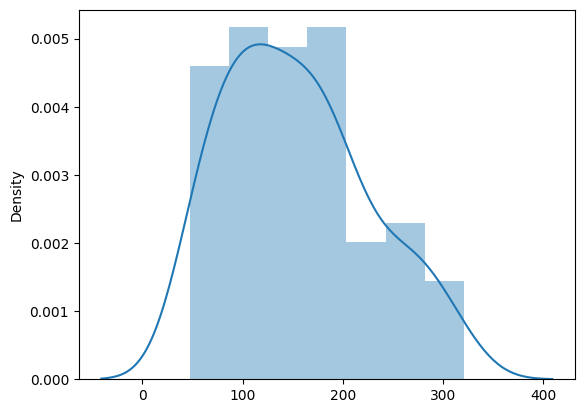

In [61]:
import seaborn as sns
sns.distplot(y_test)
pd.DataFrame(data=y_test, columns=["values"]).describe()

<ipython-input-62-25570b6d8640>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(regr_y_pred)


,values
count,89.000000
mean,156.233896
std,50.661295
min,44.591595
25%,120.742798
50%,157.376487
75%,190.878718
max,259.047470


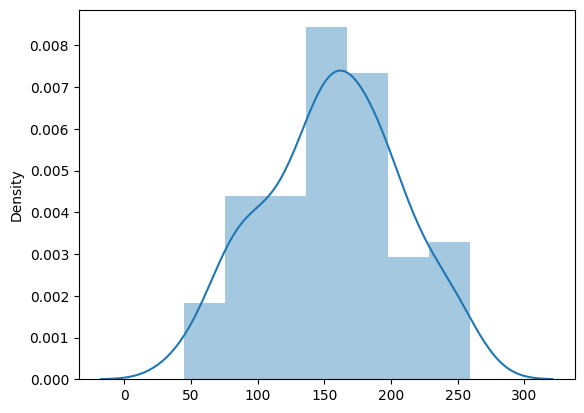

In [62]:
import seaborn as sns
sns.distplot(regr_y_pred)
pd.DataFrame(data=regr_y_pred, columns=["values"]).describe()

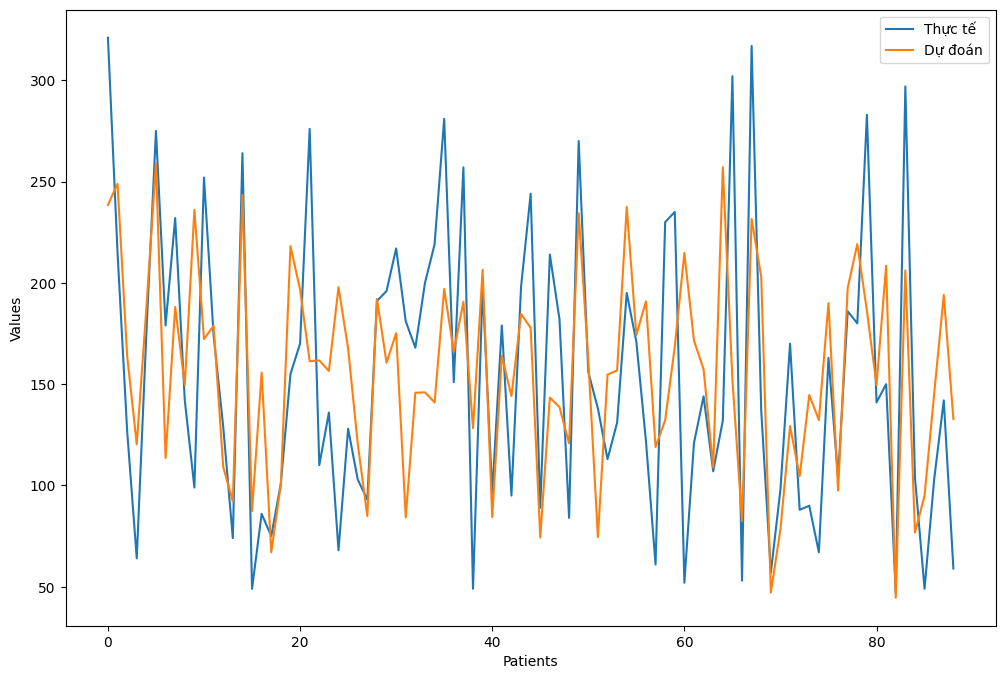

In [63]:
plt.figure(figsize=(12, 8))
plt.plot(y_test)
plt.plot(regr_y_pred)
plt.legend(['Thực tế', 'Dự đoán'])
plt.xlabel("Patients")
plt.ylabel("Values")
plt.show()

## Rigde

In [50]:
_lambda = [0, 0.0001,0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]
for _ in range(len(_lambda)):
    ridge_regr = linear_model.Ridge(alpha=_lambda[_])
    ridge_regr.fit(X_train, y_train)
    ridge_y_pred = ridge_regr.predict(X_test)
    print(f"MSE with alpha = {_lambda[_]}: {math.sqrt(mean_squared_error(y_test, ridge_y_pred))}")

MSE with alpha = 0: 58.51717127731562
MSE with alpha = 0.0001: 58.52012076109883
MSE with alpha = 0.01: 58.615666986928154
MSE with alpha = 0.04: 58.454509539463814
MSE with alpha = 0.05: 58.3855638317806
MSE with alpha = 0.06: 58.317884042393935
MSE with alpha = 0.1: 58.07419607859585
MSE with alpha = 0.5: 57.43592594678043
MSE with alpha = 1: 58.13266128093798
MSE with alpha = 5: 63.56270927834199
MSE with alpha = 10: 66.36794497714708
MSE with alpha = 20: 68.54337420937937


In [46]:
ridge_regr = linear_model.Ridge(alpha=0.1)
ridge_regr.fit(X_train, y_train)
print(f"[w1, w2,....]= {ridge_regr.coef_}")
print(f"w0= {ridge_regr.intercept_}")

[w1, w2,....]= [ -18.93029239 -205.95750389  520.88560398  278.43533926  -81.8776638
 -108.96163394 -209.97654965  117.75990964  457.61641721   69.00373659]
w0= 152.3052251107143


In [47]:
print("Giá trị dự đoán: ", ridge_regr.predict(X_test[1].reshape(1, -1)))
print("Giá trị thực tế: ", y_test[1])

Giá trị dự đoán:  [241.27351293]
Giá trị thực tế:  215.0


In [48]:
np.sum(ridge_regr.coef_ * X_test[0]) + ridge_regr.intercept_

230.86996560914235

In [ ]:
ridge_y_pred = ridge_regr.predict(X_test)


# Ex2

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [105]:
dataset_filename = '/content/drive/MyDrive/Machine Learning/Linear Regression/Lab_Exercise/elantra.csv'
df = pd.read_csv(dataset_filename)

In [106]:
df = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)
df.head(), df.tail()

(   Month  Year  ElantraSales  Unemployment  Queries  CPI_energy  CPI_all
 0      1  2010          7690           9.7      153     213.377  217.466
 1      2  2010          7966           9.8      130     209.924  217.251
 2      3  2010          8225           9.9      138     209.163  217.305
 3      4  2010          9657           9.9      132     209.024  217.376
 4      5  2010          9781           9.6      177     206.172  217.299,
     Month  Year  ElantraSales  Unemployment  Queries  CPI_energy  CPI_all
 45     10  2013         14876           7.2      223     243.374  233.782
 46     11  2013         16751           7.0      231     242.301  234.033
 47     12  2013         21692           6.7      279     246.189  234.594
 48      1  2014         15326           6.6      232     247.575  234.933
 49      2  2014         16393           6.7      240     246.389  235.169)

In [107]:
np.sum(df.isnull())

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
Month,0
Year,0
ElantraSales,0
Unemployment,0
Queries,0
CPI_energy,0
CPI_all,0


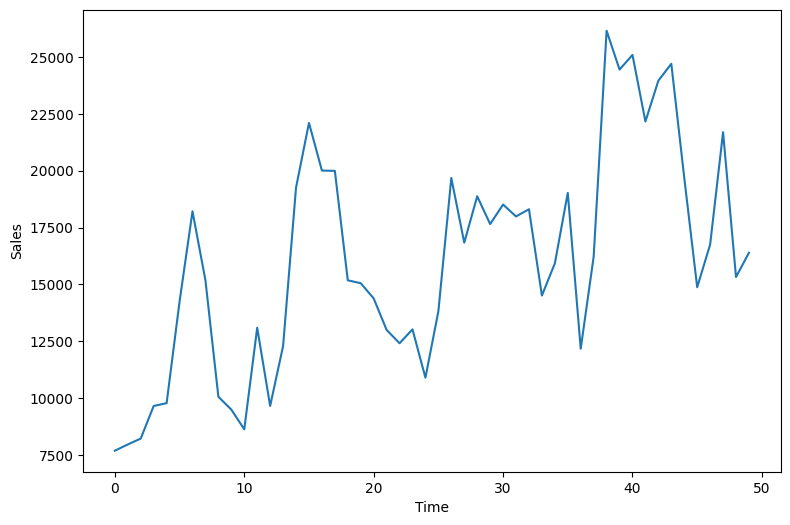

In [108]:
plt.figure(figsize=(9, 6))
plt.plot(df.ElantraSales.values)
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

In [127]:
column_to_use = ['Unemployment', 'Queries',  'CPI_energy',  'CPI_all']
df_train = df[df.Year < 2013]
df_test = df[df.Year >= 2013]
y_train = df_train.ElantraSales.values
y_test = df_test.ElantraSales.values

In [128]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df_train[column_to_use])

X_train = scaler.transform(df_train[column_to_use])
X_test = scaler.transform(df_test[column_to_use])

In [129]:
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)
regr_y_pred = regr.predict(X_test)

In [130]:
def relative_error(y_true, y_pred):
  errors = np.abs(y_true - y_pred) / y_true
  return np.mean(errors) * 100

In [131]:
rmse = math.sqrt(mean_squared_error(y_test, regr_y_pred))
re = relative_error(y_test, regr_y_pred)
print(f"RMSE: {rmse}")
print(f"Relative Error: {re}")

RMSE: 5017.347620904411
Relative Error: 18.959438416755876


In [138]:
month_onehot_train = pd.get_dummies(df_train.Month)
month_onehot_test = pd.get_dummies(df_test.Month)

In [139]:
len(month_onehot_test)

14

In [140]:
X_train = np.hstack([X_train, month_onehot_train])
X_test = np.hstack([X_test, month_onehot_test])

In [141]:
regr.fit(X_train, y_train)
new_y_pred = regr.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, new_y_pred))
re = relative_error(y_test, new_y_pred)
print(f"RMSE: {rmse}")
print(f"Relative Error: {re}")

RMSE: 3590.371340155826
Relative Error: 12.782187866064232
